In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. DATA GENERATION (Clinical Step Therapy)
# ==========================================
np.random.seed(42)
random.seed(42)

N_CLIENTS = 100
SIMULATION_DAYS = 48 * 2  # ~8 Years

CHRONIC_DISEASES = {
    "Hypertension": [
        {"name": "Lisinopril", "M_days": 30},
        {"name": "Amlodipine", "M_days": 30},
        {"name": "HCTZ", "M_days": 60}
    ],
    "Type_2_Diabetes": [
        {"name": "Metformin", "M_days": 60},
        {"name": "Glipizide", "M_days": 30},
        {"name": "Empagliflozin", "M_days": 30},
        {"name": "Insulin", "M_days": 30}
    ],
    "Asthma": [
        {"name": "Inhaled Corticosteroid", "M_days": 60},
        {"name": "Albuterol Rescue", "M_days": 90},
        {"name": "Leukotriene Modifier", "M_days": 30}
    ]
}

disease_names = list(CHRONIC_DISEASES.keys())
all_meds = []
for meds in CHRONIC_DISEASES.values():
    all_meds.extend([m["name"] for m in meds])

client_profiles = []
for client_id in range(1, N_CLIENTS + 1):
    client_profiles.append({
        "client_id": f"C_{client_id:03d}",
        "lam_doctor": np.random.uniform(0.5, 4.0),
        "lam_pharmacy": np.random.uniform(1.5, 4.5),
        "disease": np.random.choice(disease_names),
        "progression_rate": np.random.uniform(0.02, 0.15) 
    })

records = []
for client in client_profiles:
    current_day = np.random.randint(0, 30) 
    disease_med_pool = CHRONIC_DISEASES[client["disease"]]
    current_stage = 0 
    
    if client["disease"] == "Hypertension":
        pathway = [["Lisinopril"], ["Lisinopril", "Amlodipine"], ["Lisinopril", "Amlodipine", "HCTZ"]]
    elif client["disease"] == "Type_2_Diabetes":
        pathway = [["Metformin"], ["Metformin", "Glipizide"], ["Metformin", "Glipizide", "Empagliflozin"], ["Metformin", "Empagliflozin", "Insulin"]]
    
    while current_day <= SIMULATION_DAYS:
        pharmacy_delay = max(3, np.random.poisson(client['lam_pharmacy'])) 
        pharmacy_visit_day = current_day + pharmacy_delay
        if pharmacy_visit_day > SIMULATION_DAYS: break
            
        if client["disease"] == "Asthma":
            is_winter = np.sin((current_day / 365.0) * 2 * np.pi) > 0.5
            if is_winter:
                prescribed_meds_names = ["Inhaled Corticosteroid", "Albuterol Rescue", "Leukotriene Modifier"]
            else:
                prescribed_meds_names = ["Inhaled Corticosteroid"]
        else:
            if np.random.rand() < client["progression_rate"] and current_stage < len(pathway) - 1:
                current_stage += 1
            prescribed_meds_names = pathway[current_stage]

        prescribed_meds = [m for m in disease_med_pool if m["name"] in prescribed_meds_names]
        m_days = max(m["M_days"] for m in prescribed_meds)
        
        records.append({
            "client_id": client["client_id"],
            "disease": client["disease"],
            "doctor_visit_day": current_day,
            "pharmacy_report_day": pharmacy_visit_day,
            "m_days": m_days,
            "meds_received": prescribed_meds_names.copy()
        })
        current_day = pharmacy_visit_day + m_days + np.random.poisson(client['lam_doctor'])

df = pd.DataFrame(records)
print("1. Dynamic Clinical Pathway Generation Complete.")

# --- VISUALIZATION 1: COMPARISON OF VIEWS ---
print(">> Displaying Visualizations (Close the first window to see the second...)")

sample_clients = df['client_id'].unique()[:15]
raw_sample = df[df['client_id'].isin(sample_clients)]

# PLOT A: Omniscient View (Includes Doctors)
fig, ax = plt.subplots(figsize=(14, 8))
y_labels = []

for i, client in enumerate(sample_clients):
    patient_data = raw_sample[raw_sample['client_id'] == client]
    disease = patient_data['disease'].iloc[0].replace('_', ' ')
    y_labels.append(f"{client}\n({disease})")
    
    for _, row in patient_data.iterrows():
        doc_day = row['doctor_visit_day']
        rx_day = row['pharmacy_report_day']
        end_day = rx_day + row['m_days']
        
        ax.plot([rx_day, end_day], [i, i], color='darkgrey', linewidth=6, solid_capstyle='butt')
        ax.plot(doc_day, i, marker='o', color='black', markersize=8) 
        ax.plot(rx_day, i, marker='s', color='black', markersize=8)  

ax.set_yticks(range(len(sample_clients)))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Day of Simulation")
ax.set_title("Version 1: Omniscient Timeline (Includes Doctor Visits)")
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Doctor Visit', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Pharmacy Visit', markerfacecolor='black', markersize=10),
    Line2D([0], [0], color='darkgrey', lw=6, label='Medication Coverage')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()

# PLOT B: Model's View (Latent/Hidden Doctors)
fig, ax = plt.subplots(figsize=(14, 8))

for i, client in enumerate(sample_clients):
    patient_data = raw_sample[raw_sample['client_id'] == client]
    for _, row in patient_data.iterrows():
        rx_day = row['pharmacy_report_day']
        end_day = rx_day + row['m_days']
        
        ax.plot([rx_day, end_day], [i, i], color='darkgrey', linewidth=6, solid_capstyle='butt')
        ax.plot(rx_day, i, marker='s', color='black', markersize=8)  

ax.set_yticks(range(len(sample_clients)))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Day of Simulation")
ax.set_title("Version 2: The Model's View (Doctor Visits are latent/hidden)")
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_elements_2 = [
    Line2D([0], [0], marker='s', color='w', label='Pharmacy Visit', markerfacecolor='black', markersize=10),
    Line2D([0], [0], color='darkgrey', lw=6, label='Medication Coverage')
]
ax.legend(handles=legend_elements_2, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()


# ==========================================
# 2. DATA PREPROCESSING & SEQUENCE STRUCTURING
# ==========================================
print("2. Formatting Sequence History [visit_{t-k, t} -> visit_{t+1}]...")

# Calculate the precise gap between finishing meds and showing up at the pharmacy
df = df.sort_values(by=['client_id', 'pharmacy_report_day'])
df['prev_report_day'] = df.groupby('client_id')['pharmacy_report_day'].shift(1)
df['prev_m_days'] = df.groupby('client_id')['m_days'].shift(1)

# Gap = (Current Pharmacy Visit) - (Previous Visit + Supply Duration)
df['gap'] = df['pharmacy_report_day'] - (df['prev_report_day'] + df['prev_m_days'])
df['gap'] = df['gap'].clip(lower=0).fillna(0) # First visits have a gap of 0 

def build_sequence_dataset(data, seq_len=5):
    """
    Transforms flat client records into sequential blocks.
    Maps: History window of dicts -> Target dict
    """
    sequences = []
    
    for client_id, group in data.groupby('client_id'):
        group = group.sort_values('pharmacy_report_day')
        visits = group.to_dict('records')
        
        # Start at index 1 so we have at least 1 past visit to form a history
        for i in range(1, len(visits)):
            target_visit = visits[i]
            
            # Grab up to seq_len past visits
            start_idx = max(0, i - seq_len)
            history_visits = visits[start_idx:i]
            
            # Format history: list of {M (gap), meds_received}
            history_formatted = []
            for v in history_visits:
                history_formatted.append({
                    "M_gap": v['gap'],
                    "meds": v['meds_received'],
                    "m_days": v['m_days'] # Passing this along for later timeline translation
                })
                
            # Format target: {M (gap), meds_received}
            target_formatted = {
                "M_gap": target_visit['gap'],
                "meds": target_visit['meds_received']
            }
            
            sequences.append({
                "client_id": client_id,
                "disease": target_visit['disease'],
                "target_pharmacy_day": target_visit['pharmacy_report_day'],
                "history_window": history_formatted,
                "target": target_formatted
            })
            
    return pd.DataFrame(sequences)

# Build the structured sequence dataset
sequence_df = build_sequence_dataset(df, seq_len=5)

# Example output to verify structure
print("\n--- Example Sequence Output (Row 0) ---")
first_row = sequence_df.iloc[0]
print(f"Client: {first_row['client_id']} ({first_row['disease']})")
print("History Window (t-k to t):")
for idx, visit in enumerate(first_row['history_window']):
    print(f"  Step {idx+1}: Gap = {visit['M_gap']} days | Meds = {visit['meds']}")
print(f"Target (t+1):\n  Gap = {first_row['target']['M_gap']} days | Meds = {first_row['target']['meds']}")

# Time Split 
SPLIT_DAY = 48
train_seq_df = sequence_df[sequence_df['target_pharmacy_day'] < SPLIT_DAY].copy()
test_seq_df = sequence_df[sequence_df['target_pharmacy_day'] >= SPLIT_DAY].copy()

print(f"\n3. Data split complete. Train Rows: {len(train_seq_df)} | Test Rows: {len(test_seq_df)}")

In [18]:
train_seq_df

,client_id,disease,target_pharmacy_day,history_window,target
10,C_014,Hypertension,41,"[{'M_gap': 0.0, 'meds': ['Lisinopril', 'Amlodi...","{'M_gap': 3.0, 'meds': ['Lisinopril', 'Amlodip..."
29,C_030,Hypertension,47,"[{'M_gap': 0.0, 'meds': ['Lisinopril'], 'm_day...","{'M_gap': 8.0, 'meds': ['Lisinopril']}"
53,C_051,Hypertension,45,"[{'M_gap': 0.0, 'meds': ['Lisinopril'], 'm_day...","{'M_gap': 4.0, 'meds': ['Lisinopril']}"
69,C_066,Hypertension,46,"[{'M_gap': 0.0, 'meds': ['Lisinopril'], 'm_day...","{'M_gap': 7.0, 'meds': ['Lisinopril', 'Amlodip..."
72,C_068,Hypertension,44,"[{'M_gap': 0.0, 'meds': ['Lisinopril'], 'm_day...","{'M_gap': 4.0, 'meds': ['Lisinopril']}"
76,C_072,Hypertension,42,"[{'M_gap': 0.0, 'meds': ['Lisinopril'], 'm_day...","{'M_gap': 7.0, 'meds': ['Lisinopril']}"


In [2]:
import numpy as np
import pandas as pd
import random
import torch

# ==========================================
# 1. DATA GENERATION (Clinical Step Therapy)
# ==========================================
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

N_CLIENTS = 100
SIMULATION_DAYS = 30 * 24 * 4 # ~8 Years

CHRONIC_DISEASES = {
    "Hypertension": [
        {"name": "Lisinopril", "M_days": 30},
        {"name": "Amlodipine", "M_days": 30},
        {"name": "HCTZ", "M_days": 60}
    ],
    "Type_2_Diabetes": [
        {"name": "Metformin", "M_days": 60},
        {"name": "Glipizide", "M_days": 30},
        {"name": "Empagliflozin", "M_days": 30},
        {"name": "Insulin", "M_days": 30}
    ],
    "Asthma": [
        {"name": "Inhaled Corticosteroid", "M_days": 60},
        {"name": "Albuterol Rescue", "M_days": 90},
        {"name": "Leukotriene Modifier", "M_days": 30}
    ]
}

disease_names = list(CHRONIC_DISEASES.keys())
all_meds = []
for meds in CHRONIC_DISEASES.values():
    all_meds.extend([m["name"] for m in meds])

client_profiles = []
for client_id in range(1, N_CLIENTS + 1):
    client_profiles.append({
        "client_id": f"C_{client_id:03d}",
        "lam_doctor": np.random.uniform(0.5, 4.0),
        "lam_pharmacy": np.random.uniform(1.5, 4.5),
        "disease": np.random.choice(disease_names),
        # Each patient worsens at a different inherent speed
        "progression_rate": np.random.uniform(0.02, 0.15) 
    })

records = []
for client in client_profiles:
    current_day = np.random.randint(0, 30) 
    disease_med_pool = CHRONIC_DISEASES[client["disease"]]
    
    # State Machine Variables
    current_stage = 0 
    
    # Define the Clinical Pathways (Step Therapy)
    if client["disease"] == "Hypertension":
        pathway = [
            ["Lisinopril"], 
            ["Lisinopril", "Amlodipine"], 
            ["Lisinopril", "Amlodipine", "HCTZ"]
        ]
    elif client["disease"] == "Type_2_Diabetes":
        pathway = [
            ["Metformin"], 
            ["Metformin", "Glipizide"], 
            ["Metformin", "Glipizide", "Empagliflozin"], 
            ["Metformin", "Empagliflozin", "Insulin"] # Glipizide often dropped when Insulin starts
        ]
    
    while current_day <= SIMULATION_DAYS:
        pharmacy_delay = max(3, np.random.poisson(client['lam_pharmacy'])) 
        pharmacy_visit_day = current_day + pharmacy_delay
        if pharmacy_visit_day > SIMULATION_DAYS: break
            
        # --- STATE MACHINE LOGIC ---
        if client["disease"] == "Asthma":
            # Asthma is cyclical, not strictly progressive. Triggered by seasons.
            is_winter = np.sin((current_day / 365.0) * 2 * np.pi) > 0.5
            if is_winter:
                prescribed_meds_names = ["Inhaled Corticosteroid", "Albuterol Rescue", "Leukotriene Modifier"]
            else:
                prescribed_meds_names = ["Inhaled Corticosteroid"]
                
        else:
            # Linear Progression Diseases (HTN & Diabetes)
            # Roll to see if the disease worsens and bumps them to the next stage
            if np.random.rand() < client["progression_rate"] and current_stage < len(pathway) - 1:
                current_stage += 1
            
            prescribed_meds_names = pathway[current_stage]

        # Map names back to the dictionary objects
        prescribed_meds = [m for m in disease_med_pool if m["name"] in prescribed_meds_names]
            
        m_days = max(m["M_days"] for m in prescribed_meds)
        
        records.append({
            "client_id": client["client_id"],
            "disease": client["disease"],
            "pharmacy_report_day": pharmacy_visit_day,
            "m_days": m_days,
            "meds_received": prescribed_meds_names.copy()
        })
        
        current_day = pharmacy_visit_day + m_days + np.random.poisson(client['lam_doctor'])

df = pd.DataFrame(records)
print("Dynamic Clinical Pathway Generation Complete.")
# ==========================================
# 2. DATA PREPROCESSING & TIME SPLIT
# ==========================================
# Create Mappings
med_to_idx = {med: i for i, med in enumerate(all_meds)}
disease_to_idx = {d: i for i, d in enumerate(disease_names)}
num_meds = len(all_meds)
num_diseases = len(disease_names)

# Build Disease Mask (For Generative Model Constraint)
disease_mask = torch.zeros((num_diseases, num_meds))
for d_name, meds in CHRONIC_DISEASES.items():
    d_idx = disease_to_idx[d_name]
    for med in meds:
        disease_mask[d_idx, med_to_idx[med["name"]]] = 1.0

# Calculate target timelines
df = df.sort_values(by=['client_id', 'pharmacy_report_day'])
df['prev_report_day'] = df.groupby('client_id')['pharmacy_report_day'].shift(1)
df['prev_m_days'] = df.groupby('client_id')['m_days'].shift(1)
df['prev_meds'] = df.groupby('client_id')['meds_received'].shift(1)

# Drop first visits (they have no historical context to predict from)
df = df.dropna(subset=['prev_report_day']).copy()

# Target: Days between previous meds finishing and next pharmacy visit
df['target_gap'] = df['pharmacy_report_day'] - (df['prev_report_day'] + df['prev_m_days'])
df['target_gap'] = df['target_gap'].clip(lower=0) # Ensure no negatives

# Encode variables
def encode_meds(med_list):
    vec = np.zeros(num_meds)
    if isinstance(med_list, list):
        for m in med_list: vec[med_to_idx[m]] = 1.0
    return vec

df['encoded_prev_meds'] = df['prev_meds'].apply(encode_meds)
df['encoded_target_meds'] = df['meds_received'].apply(encode_meds)
df['disease_idx'] = df['disease'].map(disease_to_idx)

# Time Split (Train: Before Day 120, Test: Day 120 and onward)
SPLIT_DAY = 30 * 24 * 3
train_df = df[df['pharmacy_report_day'] < SPLIT_DAY].copy()
test_df = df[df['pharmacy_report_day'] >= SPLIT_DAY].copy()

# Convert to PyTorch Tensors
# ==========================================
# REPLACE YOUR OLD `create_tensors` WITH THIS
# ==========================================

def create_sequence_tensors(data, seq_len=5):
    """
    Builds sliding windows of history so the model can see 'seq_len' past visits.
    """
    X_seq, C_seq, Y_m, Y_g = [], [], [], []
    
    # Group by patient so we don't accidentally mix two different patients' timelines
    for client, group in data.groupby('client_id'):
        group = group.sort_values('pharmacy_report_day')
        
        # 1. Extract all features for this patient
        meds = np.stack(group['encoded_prev_meds'].values)
        gaps = group['prev_m_days'].values.reshape(-1, 1)
        feats = np.concatenate([meds, gaps], axis=1) # Shape: (Total Visits, Features)
        
        # 2. Extract all targets for this patient
        t_meds = np.stack(group['encoded_target_meds'].values)
        t_gaps = group['target_gap'].values.reshape(-1, 1)
        c_idx = group['disease_idx'].values
        
        # 3. Build the sliding window
        for i in range(len(group)):
            # Grab up to seq_len previous visits
            start_idx = max(0, i - seq_len + 1)
            window = feats[start_idx : i + 1]
            
            # If it's their 1st or 2nd visit, pad the beginning with zeros so the shape matches
            pad_len = seq_len - len(window)
            if pad_len > 0:
                padding = np.zeros((pad_len, feats.shape[1]))
                window = np.vstack([padding, window])
                
            X_seq.append(window)
            C_seq.append(c_idx[i])
            Y_m.append(t_meds[i])
            Y_g.append(t_gaps[i])
            
    # Convert lists to PyTorch tensors
    # X_seq shape is now: (Batch, Seq_Len, Features)
    return (torch.tensor(np.array(X_seq), dtype=torch.float32),
            torch.tensor(np.array(C_seq), dtype=torch.long),
            torch.tensor(np.array(Y_m), dtype=torch.float32),
            torch.tensor(np.array(Y_g), dtype=torch.float32))

# Split the data
SPLIT_DAY = 30 * 24 * 3
train_df = df[df['pharmacy_report_day'] < SPLIT_DAY].copy()
test_df = df[df['pharmacy_report_day'] >= SPLIT_DAY].copy()

# Call the NEW function instead of the old one
# (Change seq_len here to look further back in time!)
X_train, C_train, Y_meds_train, Y_gap_train = create_sequence_tensors(train_df, seq_len=5)
X_test, C_test, Y_meds_test, Y_gap_test = create_sequence_tensors(test_df, seq_len=5)


Dynamic Clinical Pathway Generation Complete.


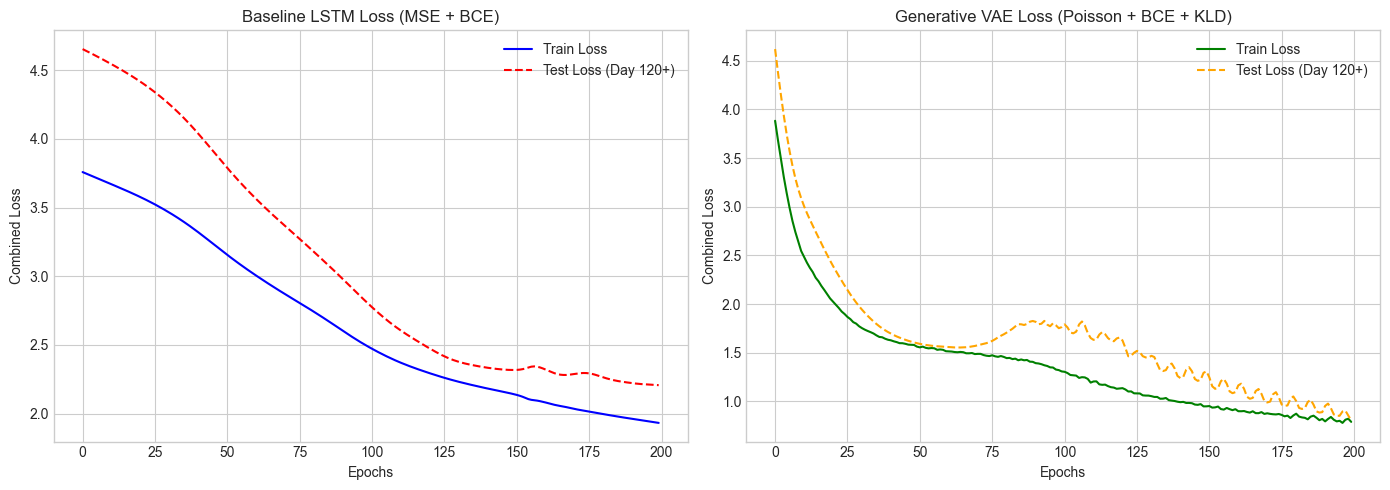

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 3. MODEL DEFINITIONS
# ==========================================

# ==========================================
# 3. MODEL DEFINITIONS (ATTENTION-VAE)
# ==========================================

class BaselineLSTM(nn.Module):
    """Baseline LSTM: Also updated to use Tanh for internal representation"""
    def __init__(self, input_size, num_meds, num_diseases, mask):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 16, batch_first=True)
        self.fc_time = nn.Linear(16, 1)
        self.fc_meds = nn.Linear(16, num_meds)
        self.register_buffer('disease_mask', mask) 
        
    def forward(self, x, context): 
        out, _ = self.lstm(x)
        hidden = torch.tanh(out[:, -1, :]) # Added Tanh here
        
        # Softplus ensures time gap is always positive without capping it like Tanh would
        pred_gap = F.softplus(self.fc_time(hidden)) 
        raw_logits = self.fc_meds(hidden) 
        
        active_mask = self.disease_mask[context]
        masked_logits = raw_logits + (1.0 - active_mask) * -1e4 
        
        return pred_gap, masked_logits


import math

class PositionalEncoding(nn.Module):
    """Injects sequence order into the Transformer so it knows Visit 1 from Visit 15"""
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class GenerativeTransformer(nn.Module):
    """Generative Autoregressive Transformer with Monte Carlo Inference"""
    def __init__(self, input_size, num_meds, num_diseases, mask, d_model=32, nhead=4, num_layers=2):
        super().__init__()
        self.disease_embedding = nn.Embedding(num_diseases, 8)
        self.register_buffer('disease_mask', mask) 
        
        # 1. ENCODER
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model*2, 
            dropout=0.2, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 2. DECODER
        # Fuse Transformer output (32) + Disease Embedding (8) = 40
        self.fc_time = nn.Linear(d_model + 8, 1)
        
        self.med_head = nn.Sequential(
            nn.Linear(d_model + 8, d_model),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(d_model, num_meds)
        )
        
    def forward(self, x, context):
        # x shape: (Batch, Seq_Len, Features)
        
        # Project inputs and add sequence positions
        x_proj = self.input_proj(x)
        x_pos = self.pos_encoder(x_proj)
        
        # Pass through Transformer
        tf_out = self.transformer(x_pos)
        
        # Grab the output representing the final time step
        h = tf_out[:, -1, :]
        
        # Context Fusion
        emb = self.disease_embedding(context)
        fused = torch.cat([h, emb], dim=1)
        
        # Outputs
        pred_log_lambda = torch.clamp(self.fc_time(fused), max=10) 
        raw_logits = self.med_head(fused)
        
        active_mask = self.disease_mask[context]
        masked_logits = raw_logits + (1.0 - active_mask) * -1e4 
        
        # We no longer return mu/logvar! Just the predictions.
        return pred_log_lambda, masked_logits

    def predict(self, x, context, gen_num=50):
        """Monte Carlo Dropout Inference to generate diverse futures"""
        # We explicitly turn ON train mode so Dropout remains active during inference
        # This causes the Transformer to explore slightly different pathways every time
        self.train() 
        
        with torch.no_grad():
            all_time_preds = []
            all_meds_preds = []
            
            for _ in range(gen_num):
                # Forward pass with active dropout acting as our "generator" noise
                pred_log_lambda, masked_logits = self(x, context)
                
                # Predict Time
                pred_gap = torch.exp(pred_log_lambda)
                all_time_preds.append(pred_gap)
                
                # Predict Meds (Convert logits to binary with fallback)
                binary_meds = (masked_logits > 0).float()
                empty_rows = (binary_meds.sum(dim=1) == 0)
                if empty_rows.any():
                    max_indices = masked_logits[empty_rows].argmax(dim=1)
                    binary_meds[empty_rows, max_indices] = 1.0
                    
                all_meds_preds.append(binary_meds)
            
            # Aggregate Results
            stacked_time = torch.stack(all_time_preds) 
            mean_time = stacked_time.mean(dim=0)       
            
            stacked_meds = torch.stack(all_meds_preds) 
            mode_meds, _ = torch.mode(stacked_meds, dim=0) 
            
            # Revert model back to eval state just to be safe
            self.eval() 
            return mean_time, mode_meds
# ==========================================
# 4. TRAINING LOOP
# ==========================================

input_dim = num_meds + 1 # prev_meds + prev_m_days
baseline_model = BaselineLSTM(input_dim, num_meds, num_diseases, disease_mask)
# Initialize the new Transformer instead of the VAE
gen_model = GenerativeTransformer(input_dim, num_meds, num_diseases, disease_mask)
# opt_gen = optim.Adam(gen_model.parameters(), lr=1e-3)
# Adjusted learning rate to match your snippet
opt_base = optim.Adam(baseline_model.parameters(), lr=1e-3)
opt_gen = optim.Adam(gen_model.parameters(), lr=1e-3)

# --- UPGRADE: DYNAMIC POSITIVE WEIGHT FOR BCE ---
# Calculate the ratio of 0s to 1s in the training set to heavily penalize missing a real medication
num_positives = Y_meds_train.sum(dim=0)
num_negatives = Y_meds_train.size(0) - num_positives
pos_weights = num_negatives / (num_positives + 1e-5) # Prevent division by zero

# Apply the weights directly to the loss function
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Other Loss Functions
mse_loss = nn.MSELoss()
poisson_loss = nn.PoissonNLLLoss(log_input=True)

epochs = 200
history = {'base_train': [], 'base_test': [], 'gen_train': [], 'gen_test': []}
def calculate_loss(model, X, C, Y_meds, Y_gap, is_gen=False):
    # Both models now return exactly 2 items!
    pred_time, pred_meds = model(X, C)
    
    if is_gen:
        # Generative Transformer: Poisson + BCE
        loss_t = poisson_loss(pred_time, Y_gap)
        loss_m = bce_loss(pred_meds, Y_meds)
        
        # Much simpler, highly stable multi-task loss
        total_loss = (loss_t * 0.1) + (loss_m * 5.0)
    else:
        # Baseline LSTM: MSE + BCE
        loss_t = mse_loss(pred_time, Y_gap)
        loss_m = bce_loss(pred_meds, Y_meds)
        total_loss = (loss_t * 0.01) + (loss_m * 5.0) 
        
    return total_loss
for epoch in range(epochs):
    # Train
    baseline_model.train()
    gen_model.train()
    
    # Baseline Step
    opt_base.zero_grad()
    loss_base = calculate_loss(baseline_model, X_train, C_train, Y_meds_train, Y_gap_train, is_gen=False)
    loss_base.backward()
    opt_base.step()
    
    # Gen Step

    opt_gen.zero_grad()
    loss_gen = calculate_loss(gen_model, X_train, C_train, Y_meds_train, Y_gap_train, is_gen=True)
    loss_gen.backward()
    
    # FIX 3: Clip gradients so massive error spikes don't destroy the weights
    torch.nn.utils.clip_grad_norm_(gen_model.parameters(), max_norm=1.0) 
    
    opt_gen.step()
    
    # Eval
    baseline_model.eval()
    gen_model.eval()
    with torch.no_grad():
        test_base = calculate_loss(baseline_model, X_test, C_test, Y_meds_test, Y_gap_test, is_gen=False)
        test_gen = calculate_loss(gen_model, X_test, C_test, Y_meds_test, Y_gap_test, is_gen=True)
    
    history['base_train'].append(loss_base.item())
    history['base_test'].append(test_base.item())
    history['gen_train'].append(loss_gen.item())
    history['gen_test'].append(test_gen.item())

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Plot
ax1.plot(history['base_train'], label='Train Loss', color='blue')
ax1.plot(history['base_test'], label='Test Loss (Day 120+)', color='red', linestyle='--')
ax1.set_title('Baseline LSTM Loss (MSE + BCE)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Combined Loss')
ax1.legend()

# Generative Model Plot
ax2.plot(history['gen_train'], label='Train Loss', color='green')
ax2.plot(history['gen_test'], label='Test Loss (Day 120+)', color='orange', linestyle='--')
ax2.set_title('Generative VAE Loss (Poisson + BCE + KLD)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Combined Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [3]:
# ==========================================
# 6. PER-USER METRICS & EVALUATION (TRANSFORMER UPGRADE)
# ==========================================
baseline_model.eval()
gen_model.eval() # gen_model.predict() will internally toggle train() for dropout

with torch.no_grad():
    # --- BASELINE INFERENCE ---
    base_pred_gap, base_pred_meds = baseline_model(X_test, C_test)
    base_loss_t = F.mse_loss(base_pred_gap, Y_gap_test, reduction='none')
    base_loss_m = F.binary_cross_entropy_with_logits(base_pred_meds, Y_meds_test, reduction='none').mean(dim=1, keepdim=True)
    # Match the loss scaling used during training
    base_total_loss = (base_loss_t * 0.01) + (base_loss_m * 5.0)
    
    # --- GENERATIVE INFERENCE (Transformer Monte Carlo) ---
    # Call the predict method to get aggregated results over 50 dropout samples
    gen_pred_gap, gen_preds_binary = gen_model.predict(X_test, C_test, gen_num=50)
    
    # Standard forward pass to calculate the Total Loss for the table metrics (No more mu/logvar!)
    gen_pred_log_lambda, gen_logits_for_loss = gen_model(X_test, C_test)
    gen_loss_t = F.poisson_nll_loss(gen_pred_log_lambda, Y_gap_test, log_input=True, reduction='none')
    gen_loss_m = F.binary_cross_entropy_with_logits(gen_logits_for_loss, Y_meds_test, reduction='none').mean(dim=1, keepdim=True)
    
    # Clean multi-task loss (No KLD)
    gen_total_loss = (gen_loss_t * 0.1) + (gen_loss_m * 5.0)

# Convert baseline logits to binary predictions using the smart thresholding function
def get_binary_predictions(logits):
    """Converts logits to binary, ensuring at least one positive prediction per visit."""
    binary = (logits > 0).float()
    empty_rows = (binary.sum(dim=1) == 0)
    if empty_rows.any():
        max_indices = logits[empty_rows].argmax(dim=1)
        binary[empty_rows, max_indices] = 1.0
    return binary

base_preds_binary = get_binary_predictions(base_pred_meds)
# gen_preds_binary is already binary directly from the .predict() method!

# --- MULTI-LABEL PER-VISIT ACCURACY METRICS ---
def calc_jaccard(preds, targets):
    """Calculates Intersection over Union per visit"""
    intersection = (preds * targets).sum(dim=1)
    union = torch.max(preds, targets).sum(dim=1)
    return (intersection / (union + 1e-8)).numpy() 

def calc_exact_match(preds, targets):
    """1.0 if the exact set of meds matches perfectly, else 0.0 per visit"""
    return (preds == targets).all(dim=1).float().numpy()

test_df['base_jaccard'] = calc_jaccard(base_preds_binary, Y_meds_test)
test_df['gen_jaccard'] = calc_jaccard(gen_preds_binary, Y_meds_test)

test_df['base_exact'] = calc_exact_match(base_preds_binary, Y_meds_test)
test_df['gen_exact'] = calc_exact_match(gen_preds_binary, Y_meds_test)

# --------------------------------------------------
test_df['base_pred_gap'] = base_pred_gap.numpy()
test_df['gen_pred_gap'] = gen_pred_gap.numpy()

test_df['base_ae'] = torch.abs(base_pred_gap - Y_gap_test).numpy()
test_df['gen_ae'] = torch.abs(gen_pred_gap - Y_gap_test).numpy()

test_df['base_loss'] = base_total_loss.numpy()
test_df['gen_loss'] = gen_total_loss.numpy()

# Group by Client to get User-Level Metrics (Average across their visits)
user_metrics = test_df.groupby('client_id').agg(
    base_mae=('base_ae', 'mean'),
    gen_mae=('gen_ae', 'mean'),
    base_jaccard=('base_jaccard', 'mean'),
    gen_jaccard=('gen_jaccard', 'mean'),
    base_exact=('base_exact', 'mean'),
    gen_exact=('gen_exact', 'mean'),
    base_loss=('base_loss', 'mean'),
    gen_loss=('gen_loss', 'mean')
).reset_index()

# ==========================================
# 7. SUMMARY STATISTICS TABLES
# ==========================================
summary_stats = pd.DataFrame({
    'Metric': [
        'Time MAE (Days)', 
        'Visit Accuracy (Jaccard/IoU)', 
        'Visit Accuracy (Exact Match Ratio)', 
        'Total Loss'
    ],
    'Baseline Mean': [
        user_metrics['base_mae'].mean(), 
        user_metrics['base_jaccard'].mean(), 
        user_metrics['base_exact'].mean(), 
        user_metrics['base_loss'].mean()
    ],
    'Baseline Std': [
        user_metrics['base_mae'].std(), 
        user_metrics['base_jaccard'].std(), 
        user_metrics['base_exact'].std(), 
        user_metrics['base_loss'].std()
    ],
    'Generative Mean': [
        user_metrics['gen_mae'].mean(), 
        user_metrics['gen_jaccard'].mean(), 
        user_metrics['gen_exact'].mean(), 
        user_metrics['gen_loss'].mean()
    ],
    'Generative Std': [
        user_metrics['gen_mae'].std(), 
        user_metrics['gen_jaccard'].std(), 
        user_metrics['gen_exact'].std(), 
        user_metrics['gen_loss'].std()
    ]
})

print("--- MODEL PERFORMANCE SUMMARY (TEST SET) ---")
print(summary_stats.round(4).to_string(index=False))
print("-" * 50)

--- MODEL PERFORMANCE SUMMARY (TEST SET) ---
                            Metric  Baseline Mean  Baseline Std  Generative Mean  Generative Std
                   Time MAE (Days)         2.8483        1.2736           1.7600          0.5902
      Visit Accuracy (Jaccard/IoU)         0.6691        0.2011           0.7430          0.2142
Visit Accuracy (Exact Match Ratio)         0.2853        0.3565           0.4978          0.3072
                        Total Loss         1.1634        0.4745           0.2649          0.4354
--------------------------------------------------


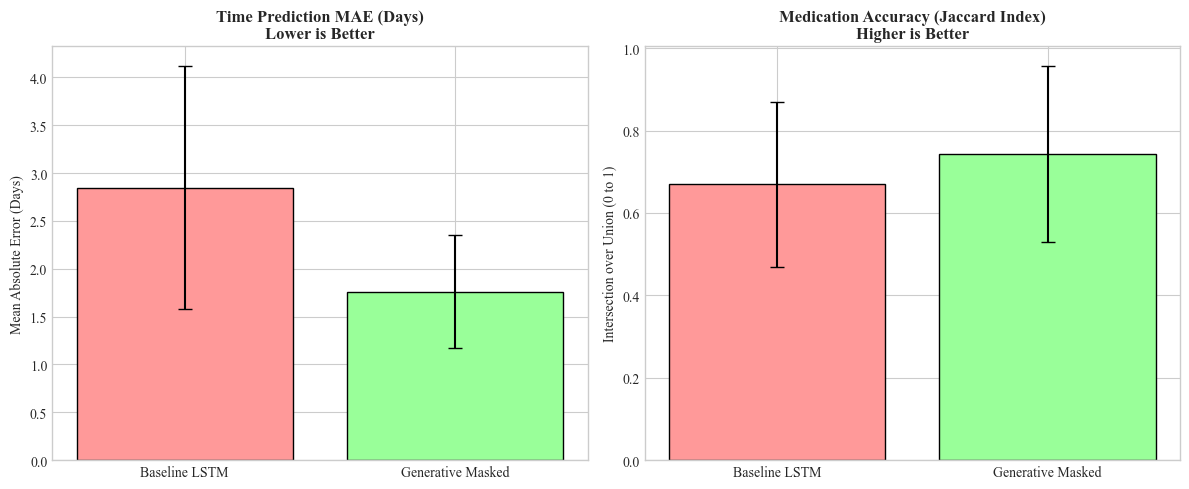

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 8. DECODE PREDICTIONS TO TEXT
# ==========================================
# Helper to convert binary vectors back to comma-separated medication strings
def decode_meds_vector(binary_matrix):
    decoded_list = []
    for row in binary_matrix:
        meds = [all_meds[i] for i, val in enumerate(row) if val > 0]
        decoded_list.append("\n".join(meds) if meds else "None")
    return decoded_list

# Add human-readable medication strings to the dataframe
test_df['true_med_names'] = test_df['meds_received'].apply(lambda x: "\n".join(x))
test_df['base_pred_med_names'] = decode_meds_vector(base_preds_binary.numpy())
test_df['gen_pred_med_names'] = decode_meds_vector(gen_preds_binary.numpy())

# ==========================================
# 9. VISUALIZATION: METRICS COMPARISON
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig_metrics, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot MAE (Lower is better)
axes[0].bar(['Baseline LSTM', 'Generative Masked'], 
            [user_metrics['base_mae'].mean(), user_metrics['gen_mae'].mean()],
            yerr=[user_metrics['base_mae'].std(), user_metrics['gen_mae'].std()],
            color=['#ff9999', '#99ff99'], capsize=5, edgecolor='black')
axes[0].set_title('Time Prediction MAE (Days)\nLower is Better', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (Days)')

# Plot Jaccard Accuracy (Higher is better)
axes[1].bar(['Baseline LSTM', 'Generative Masked'], 
            [user_metrics['base_jaccard'].mean(), user_metrics['gen_jaccard'].mean()],
            yerr=[user_metrics['base_jaccard'].std(), user_metrics['gen_jaccard'].std()],
            color=['#ff9999', '#99ff99'], capsize=5, edgecolor='black')
axes[1].set_title('Medication Accuracy (Jaccard Index)\nHigher is Better', fontweight='bold')
axes[1].set_ylabel('Intersection over Union (0 to 1)')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300)
plt.show()

# ==========================================
# 10. VISUALIZATION: TIMELINE WITH MEDS
# ==========================================
def plot_timeline_with_meds(client_id, model_prefix, title, ax):
    client_data = test_df[test_df['client_id'] == client_id].copy()
    
    # Calculate predicted day on the absolute timeline
    client_data['pred_report_day'] = client_data['prev_report_day'] + client_data['prev_m_days'] + client_data[f'{model_prefix}_pred_gap']
    
    y_true = 1
    y_pred = 0
    disease_label = client_data['disease'].iloc[0].replace('_', ' ')
    
    # Plot True Visits & Annotate Meds
    ax.plot(client_data['pharmacy_report_day'], [y_true]*len(client_data), 'go', markersize=10, label='True Visit')
    for _, row in client_data.iterrows():
        ax.plot([row['prev_report_day'] + row['prev_m_days'], row['pharmacy_report_day']], 
                [y_true, y_true], 'g-', alpha=0.3)
        
        # Annotate True Meds above the green dot
        ax.text(row['pharmacy_report_day'], y_true + 0.15, row['true_med_names'], 
                fontsize=9, ha='center', va='bottom', color='darkgreen',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgreen', boxstyle='round,pad=0.3'))
        
    # Plot Predicted Visits & Annotate Meds
    ax.plot(client_data['pred_report_day'], [y_pred]*len(client_data), 'ro', markersize=10, label='Predicted Visit')
    for _, row in client_data.iterrows():
        ax.plot([row['prev_report_day'] + row['prev_m_days'], row['pred_report_day']], 
                [y_pred, y_pred], 'r--', alpha=0.5)
        
        # Annotate Predicted Meds below the red dot
        ax.text(row['pred_report_day'], y_pred - 0.15, row[f'{model_prefix}_pred_med_names'], 
                fontsize=9, ha='center', va='top', color='darkred',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightcoral', boxstyle='round,pad=0.3'))
        
        # Draw error connection lines
        ax.plot([row['pharmacy_report_day'], row['pred_report_day']], [y_true, y_pred], 'k:', alpha=0.4)

    ax.set_yticks([y_pred, y_true])
    ax.set_yticklabels(['Model Prediction', 'Ground Truth'])
    ax.set_title(f"{title} (Client: {client_id} | Disease: {disease_label})", fontweight='bold')
    ax.set_xlabel('Simulation Day')
    ax.set_ylim(-1.0, 2.0) # Expand y-axis to fit the text boxes
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5))


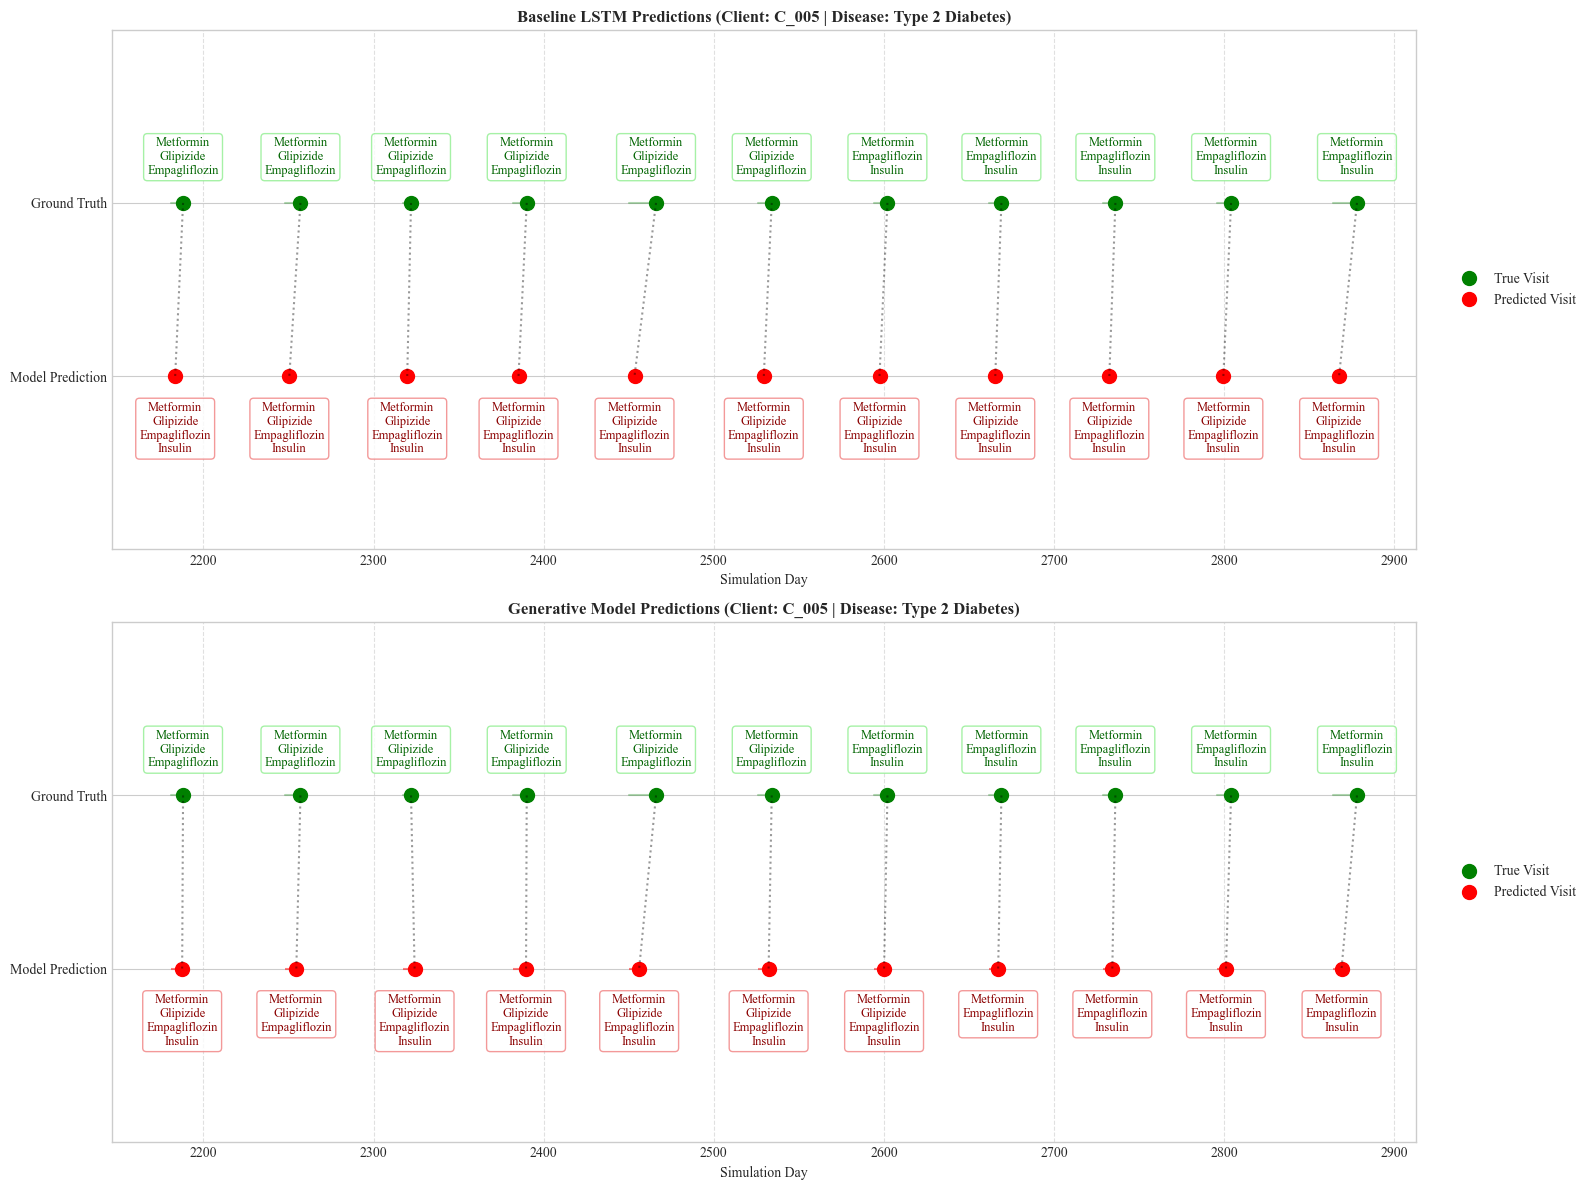

In [5]:
idx = 4
# Identify worst clients by Highest Mean Loss
worst_base_client = user_metrics.loc[idx, 'client_id']
worst_gen_client = user_metrics.loc[idx, 'client_id']

# Generate Detailed Plot
fig_timeline, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

plot_timeline_with_meds(worst_base_client, 'base', 'Baseline LSTM Predictions', ax1)
plot_timeline_with_meds(worst_gen_client, 'gen', 'Generative Model Predictions', ax2)

plt.tight_layout()
plt.savefig('timeline_with_medications.png', dpi=300, bbox_inches='tight')
plt.show()

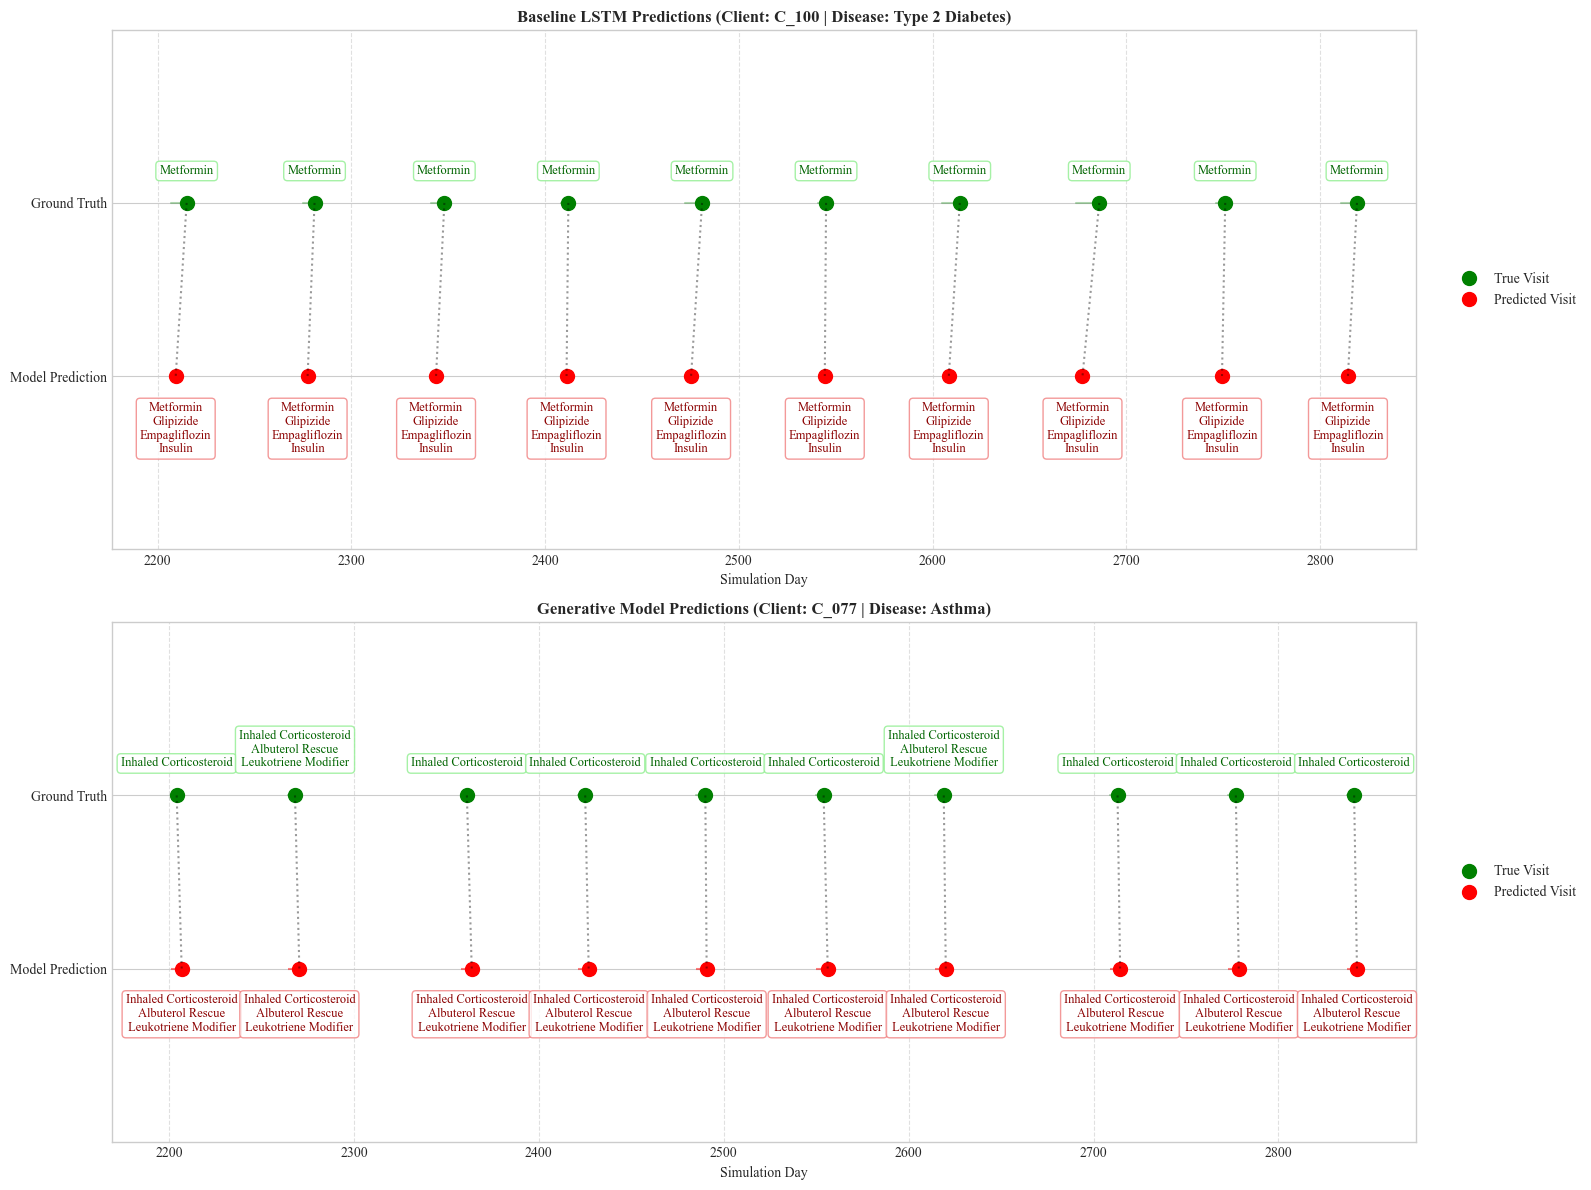

In [6]:

# Identify worst clients by Highest Mean Loss
worst_base_client = user_metrics.loc[user_metrics['base_loss'].idxmax(), 'client_id']
worst_gen_client = user_metrics.loc[user_metrics['gen_loss'].idxmax(), 'client_id']

# Generate Detailed Plot
fig_timeline, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

plot_timeline_with_meds(worst_base_client, 'base', 'Baseline LSTM Predictions', ax1)
plot_timeline_with_meds(worst_gen_client, 'gen', 'Generative Model Predictions', ax2)

plt.tight_layout()
plt.savefig('timeline_with_medications.png', dpi=300, bbox_inches='tight')
plt.show()

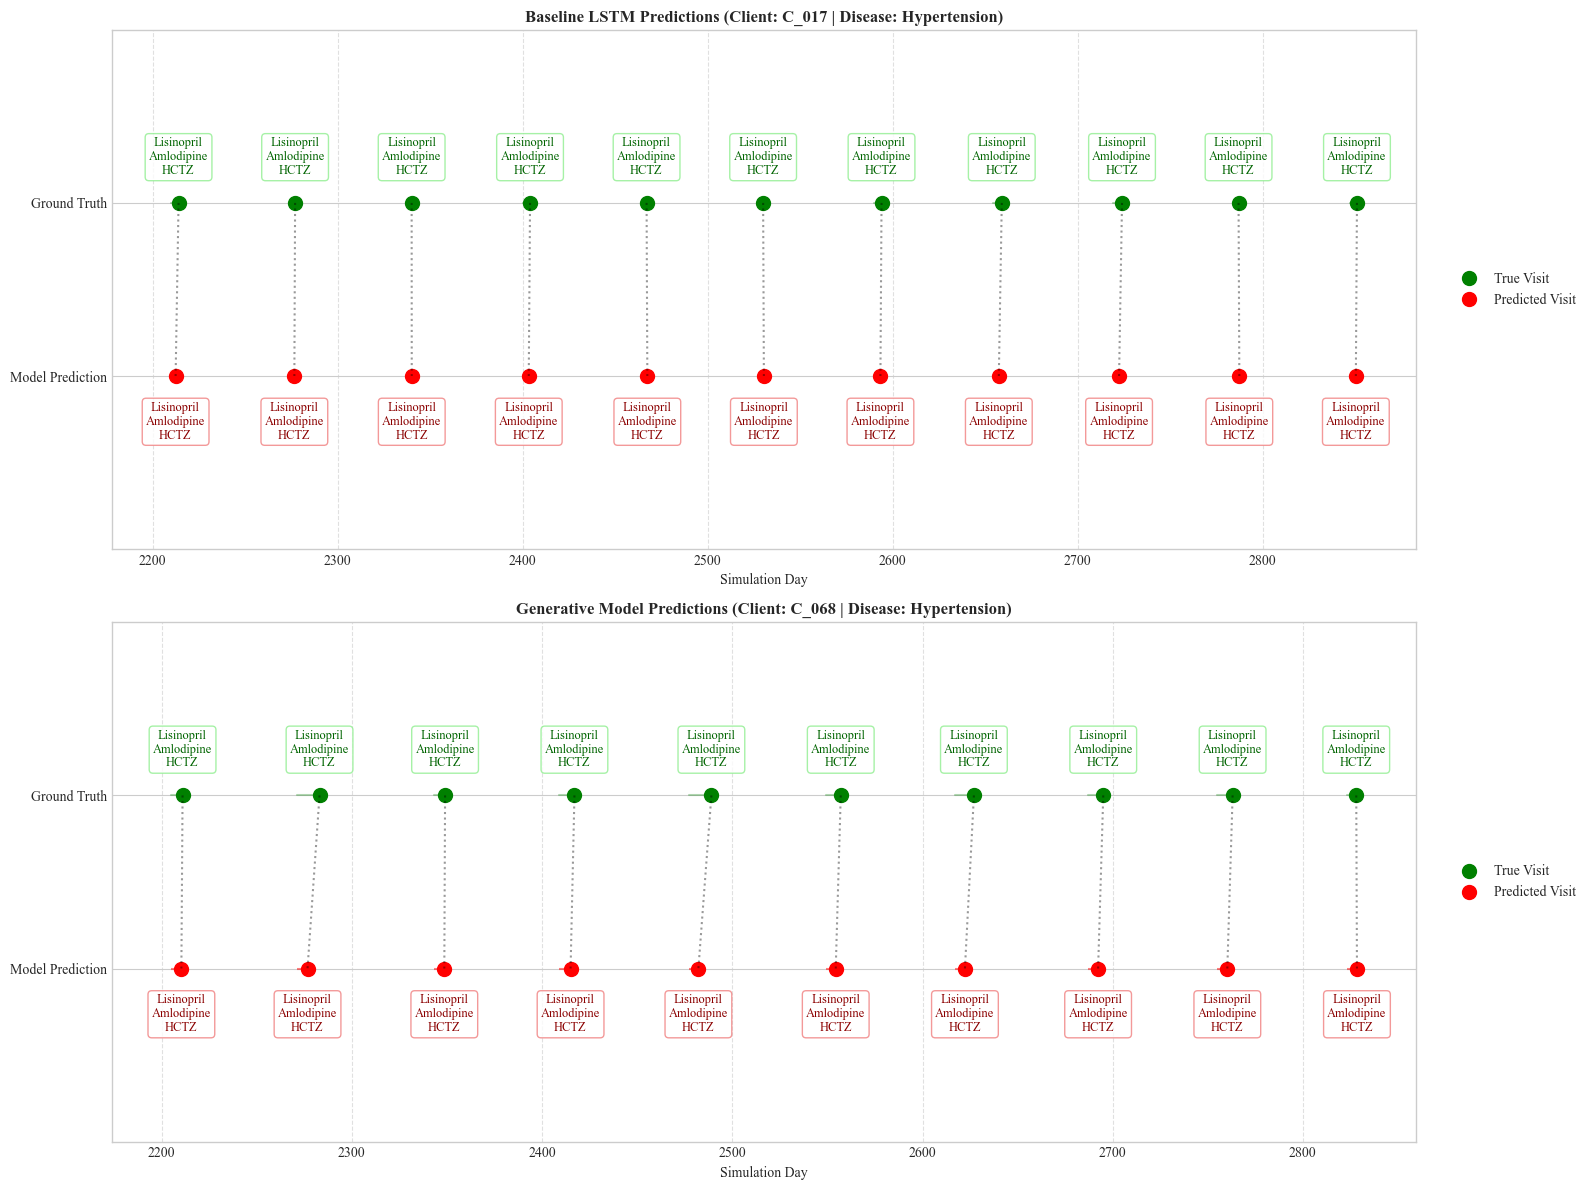

In [7]:

# Identify worst clients by Highest Mean Loss
worst_base_client = user_metrics.loc[user_metrics['base_loss'].idxmin(), 'client_id']
worst_gen_client = user_metrics.loc[user_metrics['gen_loss'].idxmin(), 'client_id']

# Generate Detailed Plot
fig_timeline, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

plot_timeline_with_meds(worst_base_client, 'base', 'Baseline LSTM Predictions', ax1)
plot_timeline_with_meds(worst_gen_client, 'gen', 'Generative Model Predictions', ax2)

plt.tight_layout()
plt.savefig('timeline_with_medications.png', dpi=300, bbox_inches='tight')
plt.show()